In [1]:
!echo $LD_LIBRARY_PATH, $CONDA_PREFIX

, /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm


In [2]:
import pyccl as ccl
import numpy as np
from scipy.integrate import simpson
import matplotlib.pyplot as plt

In [3]:
import matplotlib as mpl

mpl.use("Agg")
mpl.rcParams["font.size"] = 16
mpl.rcParams["text.usetex"] = "True"

In [4]:
Omega_b = 2.279 / 100 / 0.739**2

print(Omega_b)

0.04173067873236883


In [5]:
# cosmo = ccl.CosmologyVanillaLCDM()
# redefine cosmology with custom parameters from Cacciato+2013
cosmo = ccl.Cosmology(
    Omega_c=0.278,  # cold dark matter density
    Omega_b=Omega_b,  # baryon density
    h=0.739,  # dimensionless Hubble parameter
    n_s=0.978,  # scalar spectral index
    sigma8=0.763,  # power spectrum normalization
)
hval = cosmo["h"]
logh = np.log10(hval)
print(f"hval={hval}")
print(cosmo)

# Here we use a mass definition with Delta = 200 times the matter density,
# Note: We are defining mass w.r.t the matter density, not the critical density, which is more common in some contexts.
# keep in mind when instantiating base cl.halos.HaloProfileHOD class with mass_def and concentration-mass relation, as both should follow same rho_type convention.
# If they differ, cl.halos.HaloProfileHOD will raise an error, which is good to prevent mistakes.
hmd_200m = ccl.halos.MassDef200m
# The Duffy2008 concentration-mass relation, by default it will be initialized for S.O masses with Delta=Delta_vir of Delta_vir=200
# critical density based halo mass :math:`M_{200c}`.  (Evolution of Mvir (SO based mass even when Delta is fixed to 200) with redshift is shown below.)
cM = ccl.halos.ConcentrationDuffy08(mass_def=hmd_200m)
assert cM.mass_def == hmd_200m, "This is what you've to be careful of!"
assert cM.mass_def.name == hmd_200m.name, "Same issue"

hval=0.739
<pyccl.cosmology.Cosmology>
	Neff    = 3.044
	Omega_b = 0.04173067873236883
	Omega_c = 0.278
	h       = 0.739
	n_s     = 0.978
	sigma8  = 0.763
	extra_parameters =
	HASH_ACCURACY_PARAMS = 0x7a537f86b41c419b


In [6]:
hmd_200m?

Type:        MassDef
String form: MassDef(Delta=200, rho_type=matter)
File:        /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/massdef.py
Docstring:  
Halo mass definition. Halo masses are defined in terms of an overdensity
parameter :math:`\Delta` and an associated density :math:`X` (either the
matter density or the critical density):

.. math::
    M_\Delta = \frac{4 \pi}{3} \Delta\,\rho_X\, R_\Delta^3

where :math:`R_\Delta` is the halo radius. This object also holds methods
to translate between :math:`R_\Delta` and :math:`M_\Delta`, and to
translate masses between different definitions if a concentration-mass
relation is provided.

You may also define halo masses based on a Friends-of-Friends algorithm,
in which case simply pass ``Delta='fof'`` below.

Args:
    Delta (:obj:`float`): overdensity parameter. Pass ``'vir'`` if using virial
        overdensity. Pass ``'fof'`` for Friends-of-Friends halos.
    rho_type (:obj:`str`): either

### How the $M_{vir}$ changes with redshift even if you keep the $\Delta=200$ fixed.

In [7]:
mpl.use("inline")
%matplotlib inline

<>:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_1813391/373062917.py:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.title("Evolution of fixed $\Delta_{200m}$ with Redshift")


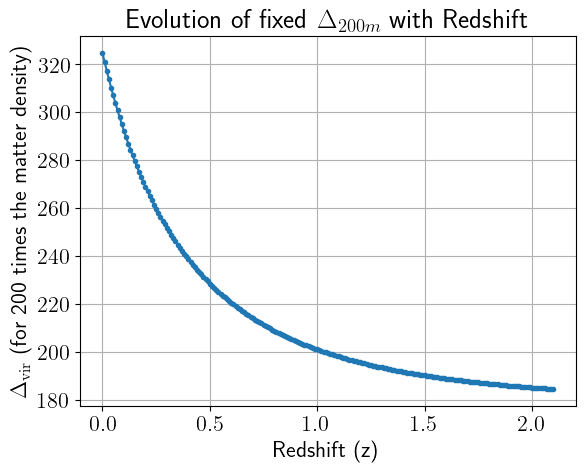

In [8]:
# Checking how Mvir evolves with redshift for this cosmology and fixed mass definition of 200 times the matter density.
# change in cosmological parameters will change this. Do you know what affects the density constrast?
z = np.linspace(0, 2.1, 211)
aa = 1 / (1 + z)
delta_vir = []
for a in aa:
    delta_vir.append(hmd_200m.get_Delta_vir(cosmo, a))

plt.cla()
plt.plot(z, delta_vir, ".-")
plt.xlabel("Redshift (z)")
plt.ylabel(r"$\Delta_{\rm vir}$ (for 200 times the matter density)")
plt.title("Evolution of fixed $\Delta_{200m}$ with Redshift")
plt.grid()
# plt.savefig("Delta_vir_vs_scaleFactor_for_M200m_mass_def.png", bbox_inches='tight', dpi=200)
plt.show()

In [9]:
ccl.halos.HaloProfileHOD?

Init signature:
ccl.halos.HaloProfileHOD(
    self,
    *,
    mass_def,
    concentration,
    log10Mmin_0=12.0,
    log10Mmin_p=0.0,
    siglnM_0=0.4,
    siglnM_p=0.0,
    log10M0_0=7.0,
    log10M0_p=0.0,
    log10M1_0=13.3,
    log10M1_p=0.0,
    alpha_0=1.0,
    alpha_p=0.0,
    fc_0=1.0,
    fc_p=0.0,
    bg_0=1.0,
    bg_p=0.0,
    bmax_0=1.0,
    bmax_p=0.0,
    a_pivot=1.0,
    ns_independent=False,
    is_number_counts=True,
)
Docstring:     
A generic halo occupation distribution (HOD)
profile describing the number density of galaxies
as a function of halo mass.

The parametrization for the mean profile is:

.. math::
   \langle n_g(r)|M,a\rangle = \bar{N}_c(M,a)
   \left[f_c(a)+\bar{N}_s(M,a) u_{\rm sat}(r|M,a)\right]

where :math:`\bar{N}_c` and :math:`\bar{N}_s` are the
mean number of central and satellite galaxies respectively,
:math:`f_c` is the observed fraction of central galaxies, and
:math:`u_{\rm sat}(r|M,a)` is the distribution of satellites
as a function of dist

In [10]:
ccl.halos.halo_model.HMCalculator.integrate_over_massfunc?

Signature:
ccl.halos.halo_model.HMCalculator.integrate_over_massfunc(
    self,
    func,
    cosmo,
    a,
)
Docstring:
Returns the integral over mass of a given funcion times
the mass function:

.. math::
    \int dM\,n(M,a)\,f(M)

Args:
    func (:obj:`callable`): a function accepting an array of halo masses
        as a single argument, and returning an array of the
        same size.
    cosmo (:class:`~pyccl.cosmology.Cosmology`): a Cosmology object.
    a (:obj:`float`): scale factor.

Returns:
    :obj:`float`: integral value.
File:      /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/halo_model.py
Type:      function

### Zecharegkas and Chang et al 2026 HOD model 

In [11]:
from typing import Union, Optional


class CacciatoHOD(ccl.halos.HaloProfileHOD):
    def __init__(
        self,
        *,
        mass_def: Union[str, ccl.halos.MassDef],
        cM_rel: Union[str, ccl.halos.Concentration],
        Lmin,
        Lmax,
        N_L=64,
        log_L0=9.95,
        lM_1=11.24,
        gamma_1=3.18,
        gamma_2=0.245,
        sigma_c=0.157,
        alpha_s=-1.18,
        b_0=-1.17,
        b_1=1.53,
        b_2=-0.217,
        fh=1.0,
        fs=1.0,
    ) -> None:
        """
        Custom HOD model based on Cacciato et al.

        Args:
            mass_def: Halo mass definition (e.g., '200m' or a MassDef object).
            cM_rel: Concentration-mass relation (e.g., 'Duffy08' or a Concentration object).
            **kwargs: Additional HOD parameters passed to the parent class.
        """
        # Initialize the parent class with essential parameters
        # overwrite more parent attr if you need.
        super().__init__(mass_def=mass_def, concentration=cM_rel)

        # fh, fs the scaling of cM_rel, to be include in _usat_real/fourier
        # b_1 and b_2 have been rescaled by h from Cacciato et al. 2013
        self.cM = cM_rel


In [12]:
# test vectorization
@np.vectorize(excluded=["x"])
def test(x, y):
    return x * 2, y * 3


print(test(3, np.arange(4)))


(array([6, 6, 6, 6]), array([0, 3, 6, 9]))


In [13]:
from scipy.special import gammaincc, gamma


@np.vectorize(excluded=["a"])
def safe_upper_gamma(a, x):
    """
    Computes the upper incomplete gamma function Γ(a, x) for any real 'a'.
    Uses the recurrence relation to handle negative 'a' values.

    Parameters:
        a (float): The shape parameter, can be any real number.
        x (float): The upper/lower limit of lower/upper-gamma function integration, must be non-negative.
    Returns:
        float: The value of the upper incomplete gamma function Γ(a, x).
    """
    # Base case: x is 0 and a <= 0, the integral diverges
    if x <= 0 and a <= 0:
        return np.inf

    # Base case: a is positive, use standard scipy
    if a > 0:
        return gammaincc(a, x) * gamma(a)

    # Recurrence relation: Γ(a, x) = (Γ(a+1, x) - x^a * e^-x) / a
    # This shifts 'a' upward until it hits the positive base case
    return (safe_upper_gamma(a + 1, x) - x**a * np.exp(-x)) / a

In [14]:
# actual parameters
cacciato_med_pars = dict(
    log_L0=9.95,  # units in paper are in Lsun/h^2
    log_M1=11.24,  # halo mass units are in Msun/h
    gamma_1=3.18,  # unitless
    gamma_2=0.245,  # unitless
    sigma_c=0.157,  # unitless
    alpha_s=-1.18,  # unitless
    b_0=-1.17,  # unitless
    b_1=1.53,  # unitless
    b_2=-0.217,  # unitless
)

# remove h-independence to work with CCL
cacciato_med_pars_h_dep = dict(
    log_L0=9.95 - 2 * logh,  # units in paper are in Lsun/h^2
    log_M1=11.24 - logh,  # halo mass units are in Msun/h
    gamma_1=3.18,  # unitless
    gamma_2=0.245,  # unitless
    sigma_c=0.157,  # unitless
    alpha_s=-1.18,  # unitless
    b_0=-1.17,  # unitless
    b_1=1.53,  # unitless
    b_2=-0.217,  # unitless
)

# sample information from cacciato et al. 2013, table 1, for the 6 luminosity bins defined by the magnitude cuts in their paper.
# the brighter edge of each magnitude is excluded, so the bins are defined as ( mag_bins[0][0], mag_bins[0][1] ], ...
mag_edges = np.linspace(-23, -17, 7)  # Mr - 5logh
mag_bins = np.array(list(zip(mag_edges[:-1], mag_edges[1:])))

print("Cacciato et al. 2013 luminosity bins defined by magnitude cuts:")
for i in range(len(mag_bins)):
    print(f"magnitude bins ({mag_bins[i][0]}, {mag_bins[i][1]}]")

# Note: Cacciato et al. compile data vectors from different studies,
# as a result, they used different samples (roughly similar) for clustering, lensing and LF measurements.
# But they model chi-square contribution of each of the data vectors using the summary info of respective samples.
# Only in the end they joinly maximize the likelihood!
# The below listed summary stats are from the clustering sample (I. Zehavi 2011)
sampleinfo = dict(
    mag_bins=mag_bins,
    zmins=np.array([0.011, 0.017, 0.027, 0.042, 0.066, 0.103]),
    zmaxs=np.array([0.026, 0.042, 0.064, 0.106, 0.159, 0.245]),
    zmeans=np.array([0.021, 0.032, 0.050, 0.082, 0.123, 0.187]),
)

# one used by Christos, with b_1 and b_2 rescaled by h=0.739
# I'm keeping this only to compare my HOD plots from his.
christos_pars = dict(
    log_L1=np.log10(1.5e7),
    log_L2=np.log10(5.6e9),
    log_L0=9.95,
    log_M1=11.24,
    gamma_1=3.18,
    gamma_2=0.245,
    sigma_c=0.157,
    alpha_s=-1.18,
    b_0=-1.17,
    b_1=1.53 * 0.739,
    b_2=-0.217 * 0.739**2,
)


def magnitude_to_luminosity(M, M_ref=4.76):
    """
    Converts absolute AB magnitude M (K+E corrected to z=0.1) to luminosity in
    units of L_sun/h^2.

    We use this function when the lens subsamples are defined on absolute
    magnitudes rather than luminosities. But the HOD model is defined in terms
    of luminosity, so we need to convert the magnitude cuts to luminosity cuts
    before computing the occupation numbers.

    $$M - 5\\log_{10}(h) = M_{\\rm ref} - 2.5\\log_{10}(L / L_{\\rm ref})$$

    Rearranging for $L$ yields the scaling factor $h^2$:
    $$L = 10^{0.4(M_{\rm ref} - M)} \\cdot h^2$$

    Parameters
    ----------
    mag : float or array_like
        Absolute AB magnitude of the source, scaled as$`M - 5\\log_{10}(h)$.
    m_ref : float, optional
        Absolute AB magnitude of the reference source (e.g., the Sun) in the
        target band. Default is 4.76 (SDSS $r$-band value from Blanton et al. 2003).

    Returns
    -------
    float or array_like
        Luminosity of the source in units of $L_{\rm ref}/h^2$ (where
        $L_{\rm ref}$ is the solar luminosity in the specified band).

    Notes
    -----
    The value of m_ref must be adjusted if working with photometric bands
    other than the SDSS $r$-band or if utilizing alternative $K+E$ correction
    baselines or no correction at all.
    """
    return 10 ** (0.4 * (M_ref - M))


Cacciato et al. 2013 luminosity bins defined by magnitude cuts:
magnitude bins (-23.0, -22.0]
magnitude bins (-22.0, -21.0]
magnitude bins (-21.0, -20.0]
magnitude bins (-20.0, -19.0]
magnitude bins (-19.0, -18.0]
magnitude bins (-18.0, -17.0]


In [15]:
mag_edges

array([-23., -22., -21., -20., -19., -18., -17.])

### CSMF model

In [62]:
bright, faint = sampleinfo["mag_bins"][0]  # M-5logh
log_L1 = np.log10(magnitude_to_luminosity(faint))  # Lsun/h^2
log_L2 = np.log10(magnitude_to_luminosity(bright))  # Lsun/h^2

print(
    f"Cacciato+2008: luminosity (Lsun/h^2) bin for the first magnitude bin {sampleinfo['mag_bins'][0]}:"
)
print(f"{log_L1:<.4e}, {log_L2:<.4e}")

Cacciato+2008: luminosity (Lsun/h^2) bin for the first magnitude bin [-23. -22.]:
1.0704e+01, 1.1104e+01


In [41]:
h_indep_params = dict(log_L1=log_L1, log_L2=log_L2, **cacciato_med_pars)
print(h_indep_params, cacciato_med_pars, sep="\n\n", end=f"\n{'----' * 10}\n")

print("Correct values to pass to the Cacciato Class:")
my_params = dict(
    log_L1=log_L1 - 2 * logh, log_L2=log_L2 - 2 * logh, **cacciato_med_pars_h_dep
)
print(my_params, cacciato_med_pars_h_dep, sep="\n\n")

{'log_L1': np.float64(10.704), 'log_L2': np.float64(11.104), 'log_L0': 9.95, 'log_M1': 11.24, 'gamma_1': 3.18, 'gamma_2': 0.245, 'sigma_c': 0.157, 'alpha_s': -1.18, 'b_0': -1.17, 'b_1': 1.53, 'b_2': -0.217}

{'log_L0': 9.95, 'log_M1': 11.24, 'gamma_1': 3.18, 'gamma_2': 0.245, 'sigma_c': 0.157, 'alpha_s': -1.18, 'b_0': -1.17, 'b_1': 1.53, 'b_2': -0.217}
----------------------------------------
Correct values to pass to the Cacciato Class:
{'log_L1': np.float64(10.966711123210349), 'log_L2': np.float64(11.366711123210347), 'log_L0': np.float64(10.212711123210347), 'log_M1': np.float64(11.371355561605174), 'gamma_1': 3.18, 'gamma_2': 0.245, 'sigma_c': 0.157, 'alpha_s': -1.18, 'b_0': -1.17, 'b_1': 1.53, 'b_2': -0.217}

{'log_L0': np.float64(10.212711123210347), 'log_M1': np.float64(11.371355561605174), 'gamma_1': 3.18, 'gamma_2': 0.245, 'sigma_c': 0.157, 'alpha_s': -1.18, 'b_0': -1.17, 'b_1': 1.53, 'b_2': -0.217}


In [42]:
my_params

{'log_L1': np.float64(10.966711123210349),
 'log_L2': np.float64(11.366711123210347),
 'log_L0': np.float64(10.212711123210347),
 'log_M1': np.float64(11.371355561605174),
 'gamma_1': 3.18,
 'gamma_2': 0.245,
 'sigma_c': 0.157,
 'alpha_s': -1.18,
 'b_0': -1.17,
 'b_1': 1.53,
 'b_2': -0.217}

In [43]:
np.linspace(8, 16, 33)  # Msun units

array([ 8.  ,  8.25,  8.5 ,  8.75,  9.  ,  9.25,  9.5 ,  9.75, 10.  ,
       10.25, 10.5 , 10.75, 11.  , 11.25, 11.5 , 11.75, 12.  , 12.25,
       12.5 , 12.75, 13.  , 13.25, 13.5 , 13.75, 14.  , 14.25, 14.5 ,
       14.75, 15.  , 15.25, 15.5 , 15.75, 16.  ])

In [44]:
hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, **my_params)
# # logM = np.linspace(8,16,128)
# Ns = hod._Ns(logM)
# Nc = hod._Nc(logM)
M = np.geomspace(10**8, 10**16, 33)
Ns = hod._Ns(M)
Nc = hod._Nc(M)

In [45]:
Ns

array([0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 0.00000000e+000,
       0.00000000e+000, 0.00000000e+000, 0.00000000e+000, 3.68049483e-230,
       6.38827528e-080, 5.69477219e-038, 3.61198367e-022, 1.20329432e-014,
       2.24973192e-010, 1.26758031e-007, 1.07227058e-005, 2.85256663e-004,
       3.50051288e-003, 2.46971884e-002, 1.15011843e-001, 3.87735815e-001,
       1.00951776e+000, 2.12660517e+000, 3.74889890e+000, 5.66527818e+000,
       7.46395140e+000])

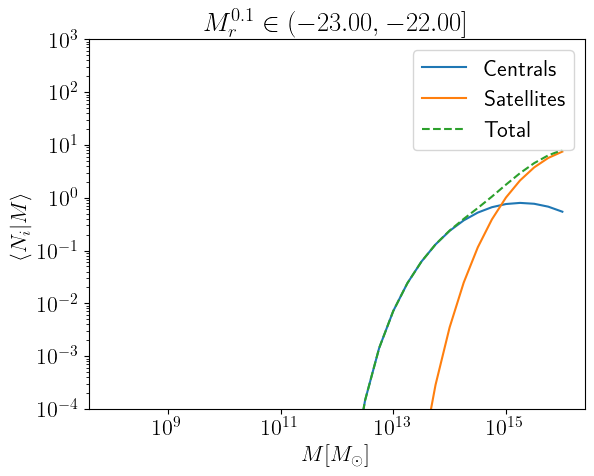

In [46]:
fig, ax = plt.subplots()
ax.loglog(M, Nc, label="Centrals")
ax.loglog(M, Ns, label="Satellites")
ax.loglog(M, Nc + Ns, "--", label="Total")
# ax.loglog(10**logM, Nc, label='Centrals')
# ax.loglog(10**logM, Ns, label='Satellites')
ax.set_ylim(1e-4, 1e3)
ax.legend()
ax.set_xlabel(r"$M [M_\odot]$")
ax.set_ylabel(r"$\langle N_i|M \rangle$")
ax.set_title(rf"$M_{{r}}^{{0.1}}\in({bright:.2f},{faint:.2f}]$")
# plt.savefig("Cacciato_HOD_Nc_Ns_vs_M.pdf", bbox_inches='tight', dpi=200)
plt.show()

/tmp/ipykernel_1813391/363483362.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


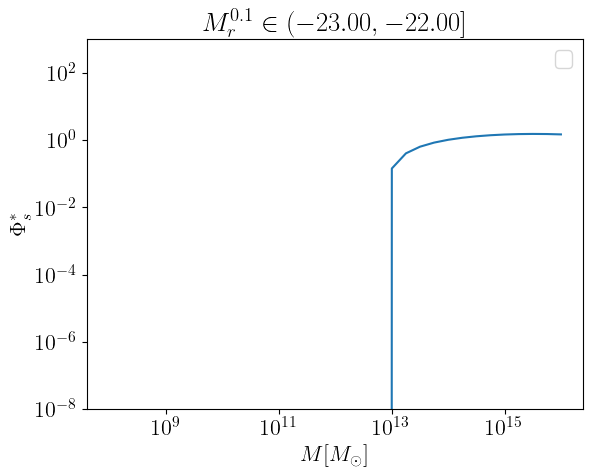

In [48]:
# Phi_star provides a cut-off HOD mass scale to avoid filling satellites to unphysical low masses.
fig, ax = plt.subplots()
ax.loglog(M, hod._log_phi_star_s(M))
ax.set_ylim(1e-8, 1e3)
ax.legend()
ax.set_xlabel(r"$M [M_\odot]$")
ax.set_ylabel(r"$\Phi_s^*$")
ax.set_title(rf"$M_{{r}}^{{0.1}}\in({bright:.2f},{faint:.2f}]$")
# plt.savefig("", bbox_inches='tight', dpi=200)
plt.show()

In [49]:
sampleinfo

{'mag_bins': array([[-23., -22.],
        [-22., -21.],
        [-21., -20.],
        [-20., -19.],
        [-19., -18.],
        [-18., -17.]]),
 'zmins': array([0.011, 0.017, 0.027, 0.042, 0.066, 0.103]),
 'zmaxs': array([0.026, 0.042, 0.064, 0.106, 0.159, 0.245]),
 'zmeans': array([0.021, 0.032, 0.05 , 0.082, 0.123, 0.187])}

## TO DO:
Think of what happens to units of each of the quantities calculated and plotted 
as the magnitudes in Cacciato are in $M_r^{0.1}-5\log h$, so the luminosities are in units 
of L_sun/h^2.  This means that the parameters log_L0, log_L1, log_L2 are all in
units of log10(L_sun/h^2).  The halo mass M is in units of $M_\odot$, so the
occupation numbers Nc and Ns are dimensionless.  

When plotting $N_c$ and $N_s$ as a function of $M$, the x-axis is in units of $M_\odot$ and the y-axis is dimensionless.  
The shape of the HOD will depend on the luminosity bin defined by $\log L_1$ and $\log L_2$, which are derived from the magnitude cuts.
log_L2, which are derived from the magnitude cuts. 

luminosity (Lsun) bin for the magnitude bin (-23.0, -22.0]:
1.1367e+01, 1.0967e+01
luminosity (Lsun) bin for the magnitude bin (-22.0, -21.0]:
1.0967e+01, 1.0567e+01
luminosity (Lsun) bin for the magnitude bin (-21.0, -20.0]:
1.0567e+01, 1.0167e+01
luminosity (Lsun) bin for the magnitude bin (-20.0, -19.0]:
1.0167e+01, 9.7667e+00
luminosity (Lsun) bin for the magnitude bin (-19.0, -18.0]:
9.7667e+00, 9.3667e+00
luminosity (Lsun) bin for the magnitude bin (-18.0, -17.0]:
9.3667e+00, 8.9667e+00


/tmp/ipykernel_1813391/4074657368.py:60: RuntimeWarning: divide by zero encountered in log10
  (c,) = ax.plot(logM, np.log10(Nc), lw=2)
/tmp/ipykernel_1813391/4074657368.py:61: RuntimeWarning: divide by zero encountered in log10
  (s,) = ax.plot(logM, np.log10(Ns), lw=2)
/tmp/ipykernel_1813391/4074657368.py:62: RuntimeWarning: divide by zero encountered in log10
  (t,) = ax.plot(logM, np.log10(Nc + Ns), "--", c="k", lw=2)
/tmp/ipykernel_1813391/4074657368.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=info)


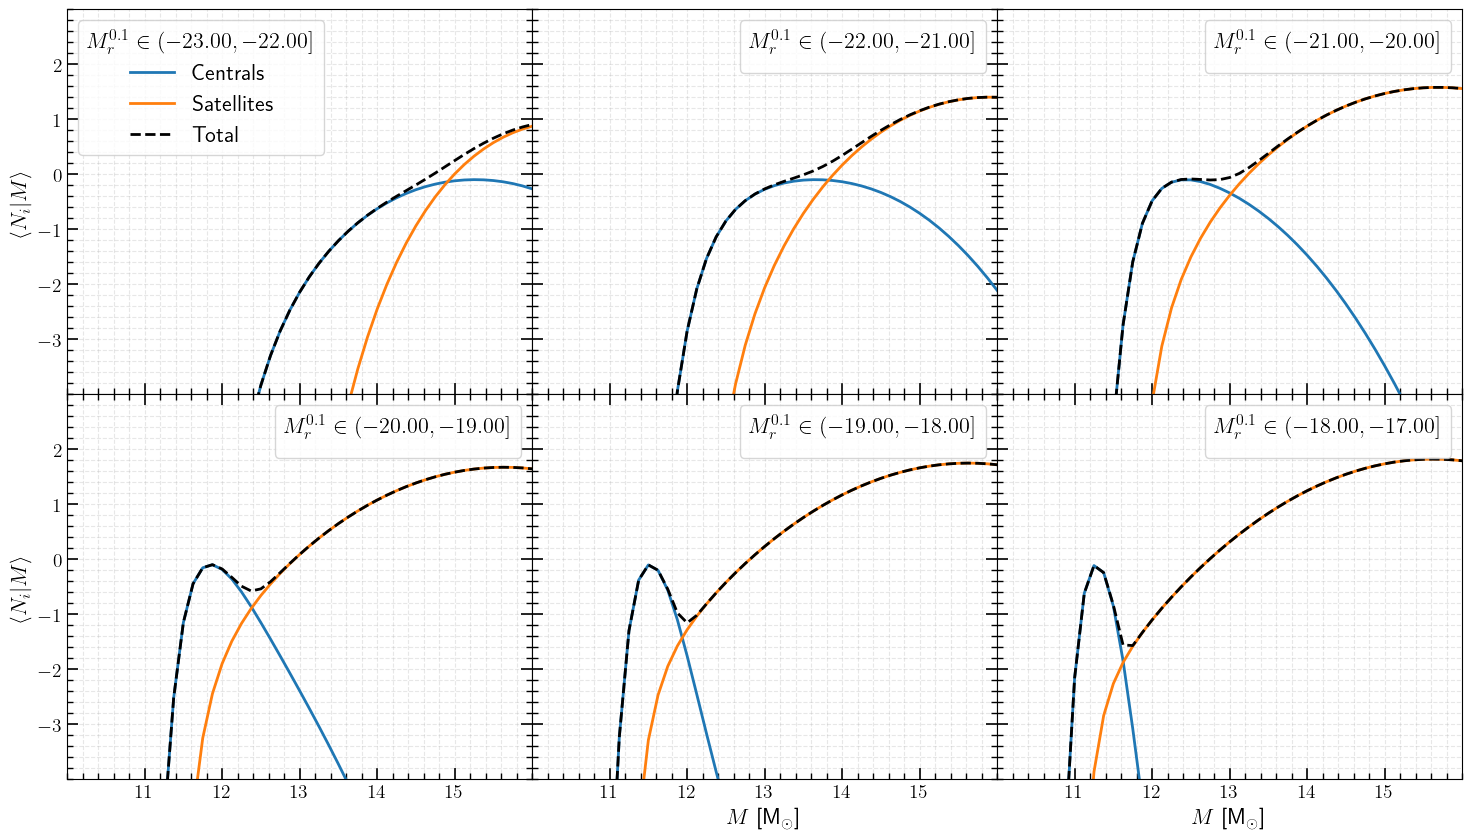

In [ ]:
from matplotlib.ticker import FixedLocator

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10),
    sharex=True,
    sharey=True,
)
# Relax horizontal spacing to avoid x-label overlap between panels
fig.subplots_adjust(hspace=0.0, wspace=0.0)

# Configure ticks: minor ticks on, ticks pointing inward, bigger tick sizes,
# and ticks enabled on all four sides (top/bottom/left/right).
for ax in axes.flat:
    ax.minorticks_on()
    # figure out this axis position (row, col) within the axes grid
    row, col = tuple(np.argwhere(axes == ax)[0].astype(int))
    # enable top/bottom ticks only for the second row (row index = 1)
    top_on = row == axes.shape[0] - 1
    # disable right ticks for the last column
    right_on = col != axes.shape[1] - 1
    ax.tick_params(
        which="major",
        direction="in",
        length=8,
        width=1.2,
        labelsize=14,
        top=top_on,
        right=right_on,
        bottom=True,
        left=True,
    )
    ax.tick_params(
        which="minor",
        direction="in",
        length=4,
        width=1.0,
        top=top_on,
        right=right_on,
        bottom=True,
        left=True,
    )
    ax.grid(True, which="both", axis="both", ls="--", alpha=0.3)

for ii, (M2, M1) in enumerate(sampleinfo["mag_bins"]):
    log_L2 = np.log10(magnitude_to_luminosity(M2)) - 2 * logh  # bright
    log_L1 = np.log10(magnitude_to_luminosity(M1)) - 2 * logh  # faint
    print(f"luminosity (Lsun) bin for the magnitude bin ({M2}, {M1}]:")
    print(f"{log_L2:<.4e}, {log_L1:<.4e}")

    my_params = dict(log_L1=log_L1, log_L2=log_L2, **cacciato_med_pars_h_dep)
    hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, **my_params)
    logM = np.linspace(8, 16, 65)  # Msun
    Ns = hod._Ns(10**logM)
    Nc = hod._Nc(10**logM)

    info = rf"$M_{{r}}^{{0.1}} \in ({M2:.2f},{M1:.2f}]$"  # Mr-5logh
    ax = axes.flatten()[ii]
    (c,) = ax.plot(logM, np.log10(Nc), lw=2)
    (s,) = ax.plot(logM, np.log10(Ns), lw=2)
    (t,) = ax.plot(logM, np.log10(Nc + Ns), "--", c="k", lw=2)
    if ii == 0:
        ax.plot([], [], color=c.get_color(), lw=2, label="Centrals")
        ax.plot([], [], color=s.get_color(), lw=2, label="Satellites")
        ax.plot([], [], "--", color=t.get_color(), lw=2, label="Total")
        ax.legend(title=info)
    else:
        ax.legend(title=info)
    if ii in [4, 5]:
        ax.set_xlabel(r"$\log_{10} M$ [M$_\odot$]")
    if ii in [0, 3]:
        ax.set_ylabel(r"$\langle N_i|M \rangle$")
    # remove the first and last major x-tick for the 2nd and 3rd columns
    # (columns indexed 1 and 2)
    if ii not in [0, 3]:
        ax.xaxis.set_major_locator(FixedLocator([11, 12, 13, 14, 15]))
        ax.yaxis.set_major_locator(FixedLocator([-3, -2, -1, 0, 1, 2]))
    ax.set_ylim(-4, 3)
    ax.set_xlim(10, 16)
plt.savefig(
    "Cacciato_HOD_Nc_Ns_vs_M_all_bins_cacciato_cosmopars.pdf",
    bbox_inches="tight",
    dpi=200,
)
plt.show()

### Make an HOD plot that is verified against some published work or a working code

My explorations with CCL

In [52]:
from pyccl.halos.halo_model import HMCalculator
from pyccl.halos.massdef import MassDef
from pyccl.halos.concentration import ConcentrationDuffy08

mass_function = ccl.halos.MassFuncTinker10(
    mass_def=hmd_200m
)  # `dn/d\log_{10}M` in units of Mpc^-3 (comoving).
halo_bias = ccl.halos.HaloBiasTinker10(mass_def=hmd_200m)
hmcalc = HMCalculator(
    mass_function=mass_function, halo_bias=halo_bias, mass_def=hmd_200m
)

In [53]:
mass_function?

Signature:     
mass_function(
    self,
    *,
    mass_def='200m',
    mass_def_strict=True,
    norm_all_z=False,
)
Call signature: mass_function(cosmo, M, a)
Type:           MassFuncTinker10
String form:   
<pyccl.halos.hmfunc.tinker10.MassFuncTinker10>
	mass_def = MassDef(Delta=200, rho_type=matter)
File:           /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/hmfunc/tinker10.py
Docstring:     
Implements the mass function of `Tinker et al. 2010
<https://arxiv.org/abs/1001.3162>`_. This parametrization accepts S.O.
masses with :math:`200 < \Delta < 3200`, defined with respect to the
matter density. This can be automatically translated to S.O. masses
defined with respect to the critical density.

Args:
    mass_def (:class:`~pyccl.halos.massdef.MassDef` or :obj:`str`):
        a mass definition object, or a name string.
    mass_def_strict (:obj:`bool`): if ``False``, consistency of the mass
        definition will be ignored.
    norm_

In [54]:
hmcalc.integrate_over_massfunc?

Signature: hmcalc.integrate_over_massfunc(func, cosmo, a)
Docstring:
Returns the integral over mass of a given funcion times
the mass function:

.. math::
    \int dM\,n(M,a)\,f(M)

Args:
    func (:obj:`callable`): a function accepting an array of halo masses
        as a single argument, and returning an array of the
        same size.
    cosmo (:class:`~pyccl.cosmology.Cosmology`): a Cosmology object.
    a (:obj:`float`): scale factor.

Returns:
    :obj:`float`: integral value.
File:      /hpc/group/cosmology/nlc38/anaconda3/envs/dp2_smhm/lib/python3.14/site-packages/pyccl/halos/halo_model.py
Type:      method

# TO DOs 
- Correct the units in the following plot
- Make sure you're using correct c-M relation and the halo mass-function as Cacciato et al. 2013
- Note, that each of the dots are computed at the redshift of the sample, so you can try to match this with the computed $\Phi(L)$ of Cacciato et al.

In [ ]:
log_lum_bin_centers = np.empty(len(sampleinfo["mag_bins"]))
mag_bin_centers = np.empty(len(sampleinfo["mag_bins"]))
phi_L_cen = np.empty_like(log_lum_bin_centers)
phi_L_sat = np.empty_like(log_lum_bin_centers)
redshifts = np.empty_like(log_lum_bin_centers)

for ii, (M2, M1) in enumerate(sampleinfo["mag_bins"]):
    log_L2 = np.log10(magnitude_to_luminosity(M2)) - 2 * logh  # bright
    log_L1 = np.log10(magnitude_to_luminosity(M1)) - 2 * logh  # faint
    print(f"luminosity bin for the magnitude bin ({M2}, {M1}]:")
    print(f"{log_L2:<.4e}, {log_L1:<.4e}")

    log_lum_bin_centers[ii] = 0.5 * (log_L1 + log_L2)
    mag_bin_centers[ii] = 0.5 * (M1 + M2)  # Mr-5logh # only needed for plot labels
    redshifts[ii] = sampleinfo["zmeans"][ii]  # mean redshift of clustering samples

    my_params = dict(log_L1=log_L1, log_L2=log_L2, **cacciato_med_pars_h_dep)
    temp_hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, **my_params)
    # Integrate over the mass function to get phi(L) for centrals and satellites
    phi_L_cen[ii] = hmcalc.integrate_over_massfunc(
        temp_hod._Nc, cosmo, 1 / (1 + redshifts[ii])
    )
    phi_L_sat[ii] = hmcalc.integrate_over_massfunc(
        temp_hod._Ns, cosmo, 1 / (1 + redshifts[ii])
    )  # check in CCL if passing of same redshift recomputes same cosmology related stuff again? for efficiency reasons?

print(redshifts)
print("Phi_sat =", phi_L_sat)
print("Phi_cen =", phi_L_cen)

luminosity bin for the magnitude bin (-23.0, -22.0]:
1.1367e+01, 1.0967e+01
luminosity bin for the magnitude bin (-22.0, -21.0]:
1.0967e+01, 1.0567e+01
luminosity bin for the magnitude bin (-21.0, -20.0]:
1.0567e+01, 1.0167e+01
luminosity bin for the magnitude bin (-20.0, -19.0]:
1.0167e+01, 9.7667e+00
luminosity bin for the magnitude bin (-19.0, -18.0]:
9.7667e+00, 9.3667e+00
luminosity bin for the magnitude bin (-18.0, -17.0]:
9.3667e+00, 8.9667e+00
[0.021 0.032 0.05  0.082 0.123 0.187]
Phi_sat = [1.28146394e-06 1.12187277e-04 7.80681256e-04 1.70296044e-03
 2.38356052e-03 2.89797729e-03]
Phi_cen = [2.08152774e-05 4.48889363e-04 1.82689322e-03 3.06461501e-03
 4.06996334e-03 5.29015058e-03]


In [56]:
def apply_custom_ticks(ax):
    ax.tick_params(
        which="major",
        direction="in",
        length=8,
        width=1.2,
        labelsize=14,
        top=True,
        right=True,
        bottom=True,
        left=True,
    )
    ax.tick_params(
        which="minor",
        direction="in",
        length=4,
        width=1.0,
        top=True,
        right=True,
        bottom=True,
        left=True,
    )
    ax.grid(True, which="both", axis="both", ls="--", alpha=0.3)
    return ax

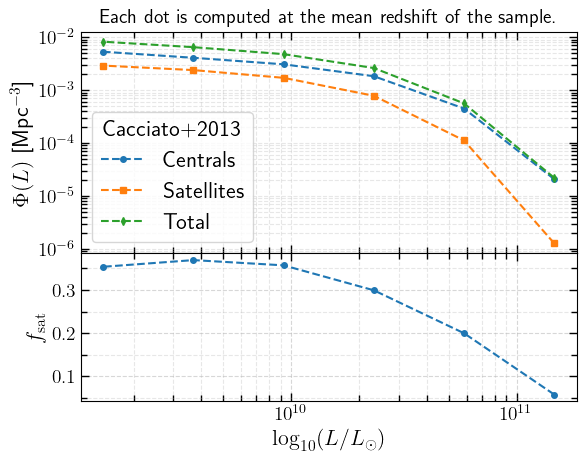

In [57]:
from matplotlib.ticker import MaxNLocator, AutoMinorLocator, MultipleLocator

fig, axes = plt.subplots(
    2,
    1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.0},
)

ax = axes[0]
ax = apply_custom_ticks(ax)
ax.loglog(
    10**log_lum_bin_centers, phi_L_cen, "o--", ms=4, label="Centrals"
)  # Lsun units
ax.loglog(
    10**log_lum_bin_centers, phi_L_sat, "s--", ms=4, label="Satellites"
)  # Lsun units
ax.loglog(
    10**log_lum_bin_centers, phi_L_cen + phi_L_sat, "d--", ms=4, label="Total"
)  # Lsun units

ax.tick_params(which="major", length=6, width=1, direction="in")
ax.tick_params(which="minor", length=4, width=1, direction="in")
# ax.set_xlabel(r"$\log_{10}(L/L_\odot)$")
ax.set_ylabel(r"$\Phi(L)$ [Mpc$^{-3}$]")
ax.legend(title="Cacciato+2013")
ax.set_title(r"Each dot is computed at the mean redshift of the sample.", fontsize=14)

ax = axes[1]
ax = apply_custom_ticks(ax)
# increase number of major ticks and enable minor ticks on the bottom subplot
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which="major", length=6, width=1, direction="in")
ax.tick_params(which="minor", length=4, direction="in")
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.5)
ax.plot(
    10**log_lum_bin_centers,
    phi_L_sat / (phi_L_cen + phi_L_sat),
    "o--",
    ms=4,
    label="Satellite Fraction",
)
ax.set_xscale("log")
ax.set_xlabel(r"$\log_{10}(L/L_\odot)$")
ax.set_ylabel(r"$f_{\rm sat}$")
# plt.savefig("Cacciato_HOD_phi_L_cen_sat_cacciato_cosmopars.pdf", bbox_inches='tight', dpi=200)
plt.show()


magnitude bin size, to get per 0.0


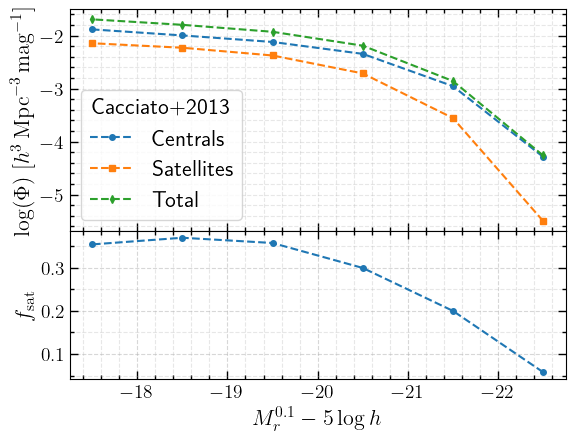

In [ ]:
# using sample redshifts from clustering data
fig, axes = plt.subplots(
    2,
    1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.0},
)

log_delta_mag = np.log10(np.diff(mag_bin_centers)[0])
print("magnitude bin size, to get per", log_delta_mag)

ax = axes[0]
ax = apply_custom_ticks(ax)
ax.xaxis.set_inverted(True)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))
ax.tick_params(which="major", length=6, width=1, direction="in")
ax.tick_params(which="minor", length=3, width=1, direction="in")
ax.plot(
    mag_bin_centers,
    np.log10(phi_L_cen) - 3 * logh - log_delta_mag,
    "o--",
    ms=4,
    label="Centrals",
)
ax.plot(
    mag_bin_centers,
    np.log10(phi_L_sat) - 3 * logh - log_delta_mag,
    "s--",
    ms=4,
    label="Satellites",
)
ax.plot(
    mag_bin_centers,
    np.log10(phi_L_cen + phi_L_sat) - 3 * logh - log_delta_mag,
    "d--",
    ms=4,
    label="Total",
)

# ax.set_xlabel(r"$\log_{10}(L/L_\odot)$")
ax.set_ylabel(r"$\log(\Phi)$ $[h^3\, {\rm Mpc}^{-3}\, {\rm mag}^{-1}]$")
ax.legend(title="Cacciato+2013")
# ax.set_title(r"Each dot is computed at the mean redshift of the sample.", fontsize=14) # at the median redshift of the clustering sample in the paper

ax = axes[1]
ax = apply_custom_ticks(ax)
ax.xaxis.set_inverted(True)
# increase number of major ticks and enable minor ticks on the bottom subplot
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.tick_params(which="major", length=6, width=1, direction="in")
ax.tick_params(which="minor", length=3, width=1, direction="in")
ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.5)
ax.plot(
    mag_bin_centers,
    phi_L_sat / (phi_L_cen + phi_L_sat),
    "o--",
    ms=4,
    label="Satellite Fraction",
)
ax.set_xlabel(r"$M^{0.1}_r-5\log h$")
ax.set_ylabel(r"$f_{\rm sat}$")
# plt.savefig("Cacciato_HOD_phi_L_cen_sat_cacciato_cosmopars.pdf", bbox_inches="tight", dpi=200)

plt.show()

## Create mass function over large number of mag bins

In [ ]:
# fixing redshift at 0.1
# delta_mr = 0.1578 # this is the magnitude bin size quoted in Cacciato and seems like a typo
mag_arr = np.linspace(-23, -18, 33)
delta_mag = np.diff(mag_arr)[0]
print("magnitude difference used to get per mag unit:", delta_mag)

mag_bins = zip(mag_arr[:-1], mag_arr[1:])

log_lum_bin_centers = np.empty(mag_arr.size - 1)
mag_bin_centers = np.empty(mag_arr.size - 1)
phi_L_cen = np.empty_like(log_lum_bin_centers)
phi_L_sat = np.empty_like(log_lum_bin_centers)

for ii, (M2, M1) in enumerate(mag_bins):
    log_L2 = np.log10(magnitude_to_luminosity(M2)) - 2 * logh  # bright
    log_L1 = np.log10(magnitude_to_luminosity(M1)) - 2 * logh  # faint
    print(f"luminosity bin for the magnitude bin ({M2}, {M1}]:")
    print(f"{log_L2:<.4e}, {log_L1:<.4e}")

    log_lum_bin_centers[ii] = 0.5 * (log_L1 + log_L2)
    mag_bin_centers[ii] = 0.5 * (M1 + M2)  # Mr-5logh # only needed for plot labels

    my_params = dict(log_L1=log_L1, log_L2=log_L2, **cacciato_med_pars_h_dep)
    temp_hod = CacciatoHOD(mass_def=hmd_200m, cM_rel=cM, **my_params)
    # Integrate over the mass function to get phi(L) for centrals and satellites
    phi_L_cen[ii] = hmcalc.integrate_over_massfunc(
        temp_hod._Nc,
        cosmo,
        1 / (1 + 0.1),  # for LF, redshift fixed to 0.1 in Cacciato+2013
    )
    phi_L_sat[ii] = hmcalc.integrate_over_massfunc(
        temp_hod._Ns,
        cosmo,
        1 / (1 + 0.1),  # for LF, redshift fixed to 0.1 in Cacciato+2013
    )  # check in CCL if passing of same redshift recomputes same cosmology related stuff again? for efficiency reasons?

print("Phi_sat =", phi_L_sat)
print("Phi_cen =", phi_L_cen)

magnitude difference used to get per mag unit: 0.15625
luminosity bin for the magnitude bin (-23.0, -22.84375]:
1.1367e+01, 1.1304e+01
luminosity bin for the magnitude bin (-22.84375, -22.6875]:
1.1304e+01, 1.1242e+01
luminosity bin for the magnitude bin (-22.6875, -22.53125]:
1.1242e+01, 1.1179e+01
luminosity bin for the magnitude bin (-22.53125, -22.375]:
1.1179e+01, 1.1117e+01
luminosity bin for the magnitude bin (-22.375, -22.21875]:
1.1117e+01, 1.1054e+01
luminosity bin for the magnitude bin (-22.21875, -22.0625]:
1.1054e+01, 1.0992e+01
luminosity bin for the magnitude bin (-22.0625, -21.90625]:
1.0992e+01, 1.0929e+01
luminosity bin for the magnitude bin (-21.90625, -21.75]:
1.0929e+01, 1.0867e+01
luminosity bin for the magnitude bin (-21.75, -21.59375]:
1.0867e+01, 1.0804e+01
luminosity bin for the magnitude bin (-21.59375, -21.4375]:
1.0804e+01, 1.0742e+01
luminosity bin for the magnitude bin (-21.4375, -21.28125]:
1.0742e+01, 1.0679e+01
luminosity bin for the magnitude bin (-21

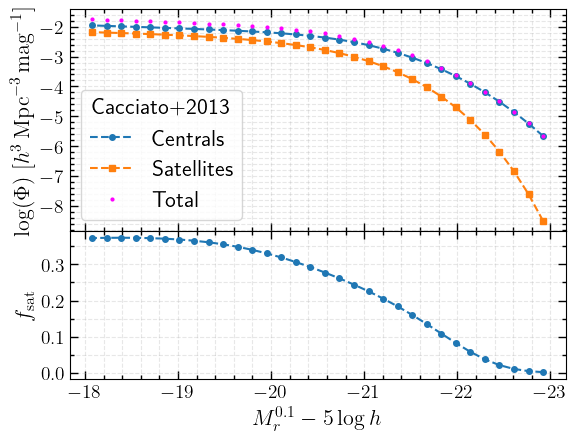

In [ ]:
fig, axes = plt.subplots(
    2,
    1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 2], "hspace": 0.0},
)
log_delta_mag = np.log10(delta_mag)

ax = axes[0]
ax = apply_custom_ticks(ax)
ax.xaxis.set_inverted(True)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))
ax.tick_params(which="major", length=6, width=1, direction="in")
ax.tick_params(which="minor", length=3, width=1, direction="in")
ax.plot(
    mag_bin_centers,
    np.log10(phi_L_cen) - 3 * logh - log_delta_mag,
    "o--",
    ms=4,
    label="Centrals",
)
ax.plot(
    mag_bin_centers,
    np.log10(phi_L_sat) - 3 * logh - log_delta_mag,
    "s--",
    ms=4,
    label="Satellites",
)
ax.plot(
    mag_bin_centers,
    np.log10(phi_L_cen + phi_L_sat) - 3 * logh - log_delta_mag,
    ".",
    color="magenta",
    ms=4,
    label="Total",
)
ax.grid(True, which="both", ls="--")
# ax.set_xlabel(r"$\log_{10}(L/L_\odot)$")
ax.set_ylabel(r"$\log(\Phi)$ $[h^3\, {\rm Mpc}^{-3}\, {\rm mag}^{-1}]$")
ax.legend(title="Cacciato+2013")
# ax.set_title(r"Each dot is computed at the mean redshift of the sample.", fontsize=14) # at the median redshift of the clustering sample in the paper

ax = axes[1]
ax = apply_custom_ticks(ax)
ax.xaxis.set_inverted(True)
# increase number of major ticks and enable minor ticks on the bottom subplot
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.yaxis.set_minor_locator(MultipleLocator(0.05))
ax.tick_params(which="major", length=6, width=1, direction="in")
ax.tick_params(which="minor", length=3, width=1, direction="in")
# ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.5)
ax.plot(
    mag_bin_centers,
    phi_L_sat / (phi_L_cen + phi_L_sat),
    "o--",
    ms=4,
    label="Satellite Fraction",
)
ax.set_xlabel(r"$M^{0.1}_r-5\log h$")
ax.set_ylabel(r"$f_{\rm sat}$")
plt.savefig(
    "Cacciato_HOD_phi_L_cen_sat_cacciato_cosmopars_z0.1.pdf",
    bbox_inches="tight",
    dpi=200,
)
# Even after taking z=0.1, as instructed in Cacciato et al 2013, matching to
# fiducial cosmology, still I'm not able to reproduce the LF and satellite
# fractions.

plt.show()

### Overdensity evolution,  critical vs mean 

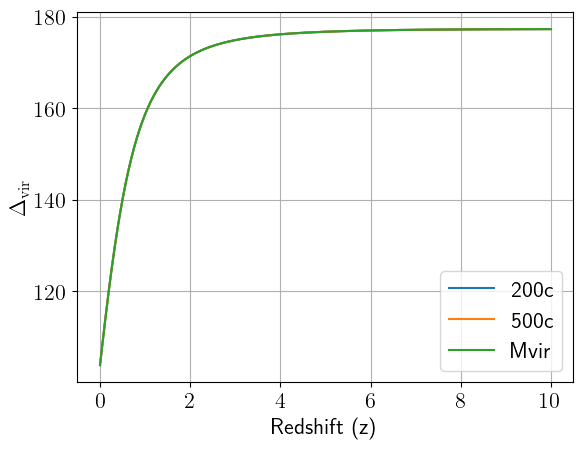

In [97]:
# Checking how Delta_vir evolves with redshift for this cosmology and fixed mass definition of 200 times the matter density.
hmd_200m = ccl.halos.MassDef200m
hmd_200c = ccl.halos.MassDef200c
hmd_500c = ccl.halos.MassDef500c
hmd_mvir = ccl.halos.MassDefVir
hmd_fof = ccl.halos.MassDefFof

z = np.linspace(0, 10.0, 1001)
a = 1 / (1 + z)

plt.cla()
# plt.plot(z, hmd_200m.get_Delta_vir(cosmo,a), "--", label="200m")
plt.plot(z, hmd_200c.get_Delta_vir(cosmo, a), label="200c")
plt.plot(z, hmd_500c.get_Delta_vir(cosmo, a), label="500c")
plt.plot(z, hmd_mvir.get_Delta_vir(cosmo, a), label="Mvir")
# plt.plot(z, hmd_fof.get_Delta_vir(cosmo,a), label="fof")
plt.xlabel("Redshift (z)")
plt.ylabel(r"$\Delta_{\rm vir}$")
plt.grid()
plt.legend()
# plt.savefig("Delta_vir_vs_scaleFactor_for_M200m_mass_def.png", bbox_inches='tight', dpi=200)
plt.show()

In [98]:
from pyccl.halos.massdef import mass_translator

# Define the input mass definition and value
mdef_in = ccl.halos.MassDef200m
M_in = 1e14  # Solar masses

# Define the target mass definitions
mdef_out_200c = ccl.halos.MassDef200c
mdef_out_500c = ccl.halos.MassDef500c

# Use a concentration relation (e.g., Duffy 2008) to perform the conversion
concentration_model = ccl.halos.ConcentrationDuffy08(mass_def=mdef_in)

# Translate mass at redshift z = 0
z = np.linspace(0, 10.0, 1001)
a = 1 / (1 + z)

translator_200c = mass_translator(
    mass_in=mdef_in, mass_out=mdef_out_200c, concentration=concentration_model
)
translator_500c = mass_translator(
    mass_in=mdef_in, mass_out=mdef_out_500c, concentration=concentration_model
)

M_200c = translator_200c(cosmo, M_in, a)
M_500c = translator_500c(cosmo, M_in, a)

print(f"Input Mass (200m): {M_in:.2e} M_sun")
print(f"Converted (200c):  {M_200c:.2e} M_sun")
print(f"Converted (500c):  {M_500c:.2e} M_sun")


def plot_it():
    plt.cla()
    plt.plot(z, M_200c, label="M_200c")
    plt.plot(z, M_500c, label="M_500c")
    plt.show()


plot_it()


TypeError: in method 'convert_concentration_vec', argument 2 of type 'double'